Installs

In [48]:
%pip install pandas
%pip install emoji
%pip install pip setuptools wheel
%pip install spacy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Imports

In [49]:
from pathlib import Path
import pandas as pd
import emoji
import spacy
import plotly.express as px
import matplotlib.pyplot as plt
from collections import Counter
nlp = spacy.load("es_core_news_sm")

In [50]:

# Paths
PROJ_ROOT = Path.cwd().parent
DATA_PATH = PROJ_ROOT / "data" / "processed" / "whatsapp_messages.csv"

# Load processed dataset
df = pd.read_csv(
    DATA_PATH,
    parse_dates=["datetime"],
)

df.head()

,message_id,datetime,date,time,year,month,day,day_of_week,hour,sender,content_type,is_forwarded,has_url,url,has_caption,message_length,word_count,content,text
0,1,2018-09-03 16:40:00,2018-09-03,16:40:00,2018,9,3,Monday,16,Eevee,text,False,False,NaN,False,15,2,<Media omitted>,<Media omitted>
1,2,2018-09-03 16:40:00,2018-09-03,16:40:00,2018,9,3,Monday,16,Eevee,text,False,False,NaN,False,15,2,<Media omitted>,<Media omitted>
2,3,2018-09-03 16:40:00,2018-09-03,16:40:00,2018,9,3,Monday,16,Eevee,text,False,False,NaN,False,15,2,<Media omitted>,<Media omitted>
3,4,2018-09-03 16:40:00,2018-09-03,16:40:00,2018,9,3,Monday,16,Eevee,text,False,False,NaN,False,15,2,<Media omitted>,<Media omitted>
4,5,2018-09-03 16:40:00,2018-09-03,16:40:00,2018,9,3,Monday,16,Eevee,text,False,False,NaN,False,15,2,<Media omitted>,<Media omitted>


Mensajes por miembro

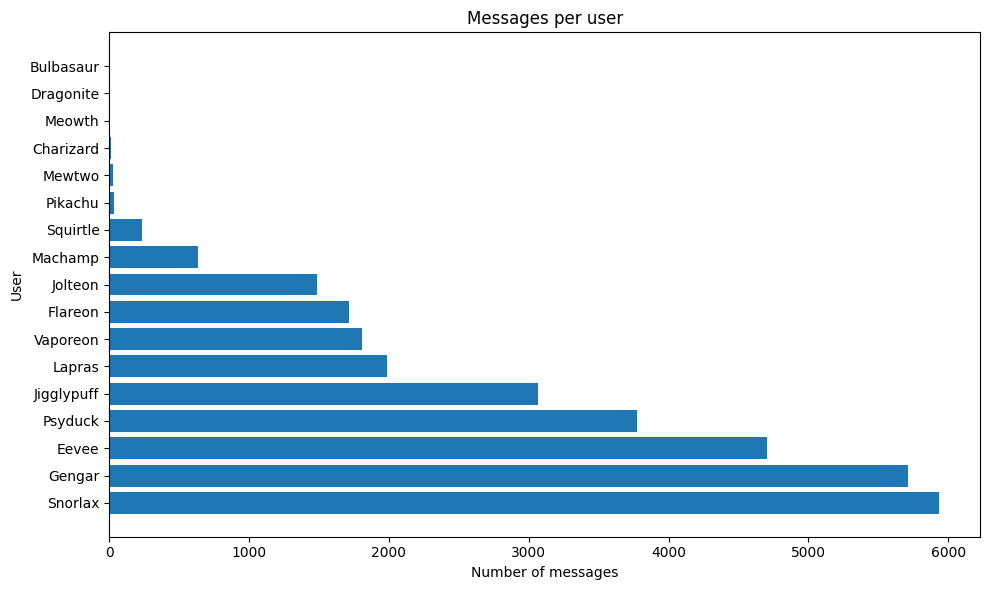

In [51]:
# Messages per participant as a DataFrame
messages_per_person = (
    df.groupby("sender")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="messages")
)

messages_per_person.head(1)

# Gráfica plotly
fig = px.bar(
    messages_per_person,
    x="sender",
    y="messages",
    title="Messages per user",
    labels={
        "sender": "User",
        "messages": "Number of messages"
    }
)

fig.show()

## Matplotlib graph
plt.figure(figsize=(10, 6))

plt.barh(
    messages_per_person["sender"],
    messages_per_person["messages"],
)

plt.xlabel("Number of messages")
plt.ylabel("User")
plt.title("Messages per user")

plt.tight_layout()
plt.show()

¿Cual es la frecuencia promedio de palabras por mensaje de texto de cada usuario?

In [52]:
# Filter only text messages
text_messages = df[df["content_type"] == "text"]

# Average words per text message by user
avg_words_per_user = (
    text_messages
    .groupby("sender")["word_count"]
    .mean()
    .sort_values(ascending=False)
    .reset_index(name="avg_words_per_message")
)

avg_words_per_user.iloc[0]

sender                   Dragonite
avg_words_per_message         24.0
Name: 0, dtype: object

Usuario que envía más palabras

In [53]:
words_per_user = (
    df.groupby("sender")["word_count"]
    .sum()
    .sort_values(ascending=False)
)

words_per_user

top_words_user = words_per_user.idxmax()
top_words = words_per_user.max()

print(f"{top_words_user} es quien más palabras envía: {top_words} palabras.")

Gengar es quien más palabras envía: 28802 palabras.


¿Quién manda más emojis?

In [54]:
def count_emojis(text):
    if not isinstance(text, str):
        return 0

    return len(emoji.emoji_list(text))


df["emoji_count"] = df["content"].apply(count_emojis)

emojis_per_user = (
    df.groupby("sender")["emoji_count"]
    .sum()
    .sort_values(ascending=False)
)

emojis_per_user
top_emoji_user = emojis_per_user.idxmax()
top_emojis = emojis_per_user.max()

print(f"{top_emoji_user} es quien más emojis envía: {top_emojis} emojis.")

Snorlax es quien más emojis envía: 549 emojis.


Quién Envía más media (la información de sticker no se manda bien en un chat extenso)

In [55]:
stickers_per_user = (
    df[df["content_type"] == "sticker"]
    .groupby("sender")
    .size()
    .sort_values(ascending=False)
)

stickers_per_user

# top_sticker_user = stickers_per_user.idxmax()
# top_stickers = stickers_per_user.max()

# print(
#     f"{top_sticker_user} es quien más stickers envía: "
#     f"{top_stickers} stickers."
# )


Series([], dtype: int64)

Análisis semanal

In [56]:
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

messages_by_day = (
    df["day_of_week"]
    .value_counts()
    .reindex(days_order)
    .reset_index()
)

messages_by_day.columns = ["day_of_week", "messages"]

messages_by_day

,day_of_week,messages
0,Monday,3078
1,Tuesday,4323
2,Wednesday,5578
3,Thursday,4640
4,Friday,5914
5,Saturday,4920
6,Sunday,2663


In [57]:
most_active_day = messages_by_day.loc[
    messages_by_day["messages"].idxmax()
]

least_active_day = messages_by_day.loc[
    messages_by_day["messages"].idxmin()
]

print(
    f"Día con más mensajes: "
    f"{most_active_day['day_of_week']} "
    f"({most_active_day['messages']} mensajes)"
)

print(
    f"Día con menos mensajes: "
    f"{least_active_day['day_of_week']} "
    f"({least_active_day['messages']} mensajes)"
)

Día con más mensajes: Friday (5914 mensajes)
Día con menos mensajes: Sunday (2663 mensajes)


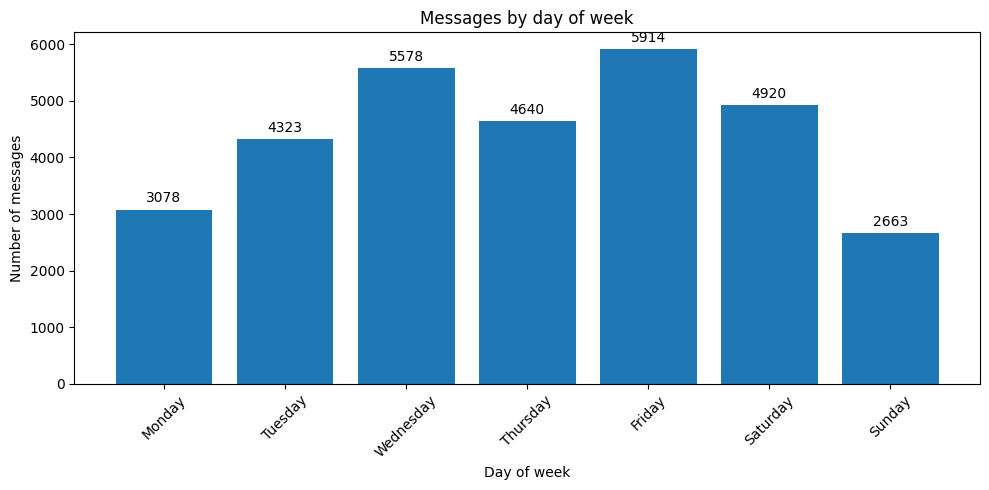

In [58]:
# plotly graph
fig = px.bar(
    messages_by_day,
    x="day_of_week",
    y="messages",
    title="Messages by day of week",
    labels={
        "day_of_week": "Day of week",
        "messages": "Number of messages",
    },
    text="messages",
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    width=1000,
    height=500,
    showlegend=False,
)

fig.show()

# matplotlib graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    messages_by_day["day_of_week"],
    messages_by_day["messages"],
)

plt.xlabel("Day of week")
plt.ylabel("Number of messages")
plt.title("Messages by day of week")

# Mostrar el número de mensajes encima de cada barra
plt.bar_label(
    bars,
    padding=3
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Mensajes por hora

In [59]:
messages_by_hour = (
    df.groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
    .reset_index(name="messages")
)

messages_by_hour

,hour,messages
0,0,353
1,1,160
2,2,106
3,3,78
4,4,59
5,5,61
6,6,108
7,7,245
8,8,1070
9,9,1834


In [60]:
most_active_hour = messages_by_hour.loc[
    messages_by_hour["messages"].idxmax()
]

least_active_hour = messages_by_hour.loc[
    messages_by_hour["messages"].idxmin()
]

print(
    f"Hora con más mensajes: "
    f"{int(most_active_hour['hour']):02d}:00 "
    f"({most_active_hour['messages']} mensajes)"
)

print(
    f"Hora con menos mensajes: "
    f"{int(least_active_hour['hour']):02d}:00 "
    f"({least_active_hour['messages']} mensajes)"
)

Hora con más mensajes: 12:00 (2927 mensajes)
Hora con menos mensajes: 04:00 (59 mensajes)


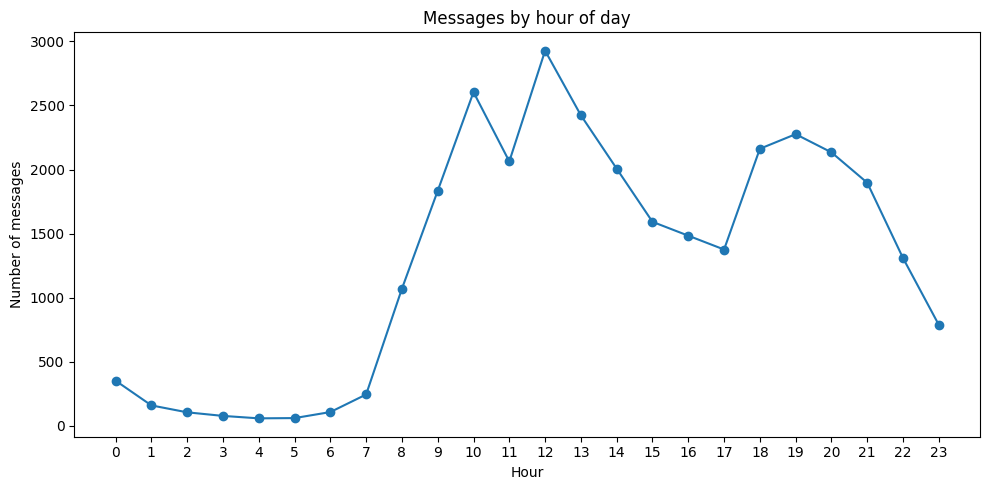

In [61]:
# plotly
fig = px.line(
    messages_by_hour,
    x="hour",
    y="messages",
    markers=True,
    title="Messages by hour of day",
    labels={
        "hour": "Hour",
        "messages": "Number of messages"
    }
)

fig.update_xaxes(dtick=1)

fig.show()

# matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    messages_by_hour["hour"],
    messages_by_hour["messages"],
    marker="o",
)

plt.xlabel("Hour")
plt.ylabel("Number of messages")
plt.title("Messages by hour of day")

# Mostrar todas las horas de 0 a 23
plt.xticks(range(24))

plt.tight_layout()
plt.show()

Palabras más utilizadas

In [62]:
text_messages = df[
    (df["content_type"] == "text")
    & df["text"].notna()
].copy()



def extract_all_words(text):
    doc = nlp(text)

    return [
        token.text.lower()
        for token in doc
        if token.is_alpha
    ]


all_words = []

for text in text_messages["text"]:
    all_words.extend(extract_all_words(text))


word_counts = Counter(all_words)

most_common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

most_common_words

,word,count
0,media,7319
1,omitted,7303
2,el,3435
3,que,3102
4,de,2940
5,a,2721
6,la,2669
7,no,2052
8,en,1747
9,y,1572


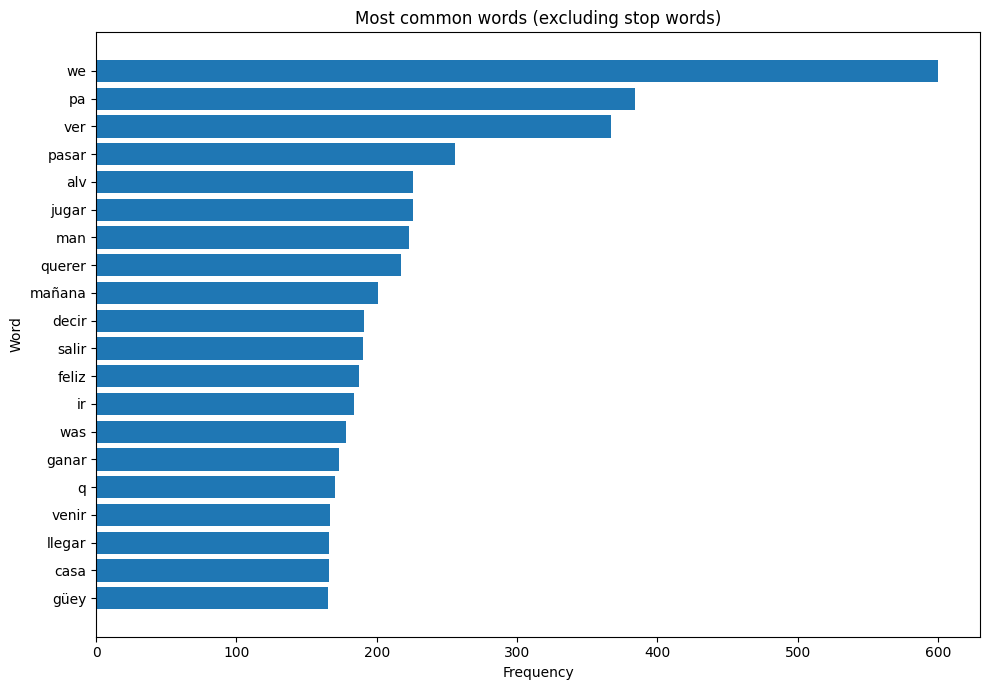

In [63]:
CUSTOM_STOP_WORDS = {
    "message",
    "omitted",
    "this",
    "medio"
}

def extract_relevant_words(text):
    doc = nlp(text)

    return [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha
        and not token.is_stop
        and token.lemma_.lower() not in CUSTOM_STOP_WORDS
    ]


relevant_words = []

for text in text_messages["text"]:
    relevant_words.extend(extract_relevant_words(text))


relevant_word_counts = Counter(relevant_words)

most_common_without_stopwords = pd.DataFrame(
    relevant_word_counts.most_common(20),
    columns=["word", "count"]
)

most_common_without_stopwords

# plotly graph
fig = px.bar(
    most_common_without_stopwords,
    x="count",
    y="word",
    orientation="h",
    title="Most common words (excluding stop words)",
    labels={
        "word": "Word",
        "count": "Frequency"
    }
)

fig.show()

# matplotlib graph
plt.figure(figsize=(10, 7))

plt.barh(
    most_common_without_stopwords["word"],
    most_common_without_stopwords["count"],
)

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Most common words (excluding stop words)")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Palabras más usadas por usuario

In [64]:
def most_common_words_by_user(group, n=10):
    words = []

    for text in group["text"].dropna():
        words.extend(extract_relevant_words(text))

    return Counter(words).most_common(n)

rows = []

for sender, group in text_messages.groupby("sender"):
    common_words = most_common_words_by_user(group, n=10)

    for rank, (word, count) in enumerate(common_words, start=1):
        rows.append({
            "sender": sender,
            "rank": rank,
            "word": word,
            "count": count,
        })

top_words_by_user = pd.DataFrame(rows)

top_words_by_user

,sender,rank,word,count
0,Bulbasaur,1,saaa,1
1,Bulbasaur,2,joya,1
2,Bulbasaur,3,pensar,1
3,Bulbasaur,4,tumblr,1
4,Charizard,1,jajajaja,2
...,...,...,...,...
154,Vaporeon,6,llegar,32
155,Vaporeon,7,pa,32
156,Vaporeon,8,mañana,25
157,Vaporeon,9,ver,24


Miembro en particular

In [65]:
top_words_by_user[
    top_words_by_user["sender"] == "Vaporeon"
]

,sender,rank,word,count
149,Vaporeon,1,we,91
150,Vaporeon,2,jaja,59
151,Vaporeon,3,jugar,58
152,Vaporeon,4,man,52
153,Vaporeon,5,xd,35
154,Vaporeon,6,llegar,32
155,Vaporeon,7,pa,32
156,Vaporeon,8,mañana,25
157,Vaporeon,9,ver,24
158,Vaporeon,10,feliz,24


In [66]:
top_word_per_user = (
    top_words_by_user[
        top_words_by_user["rank"] == 1
    ]
    .reset_index(drop=True)
)

top_word_per_user

,sender,rank,word,count
0,Bulbasaur,1,saaa,1
1,Charizard,1,jajajaja,2
2,Dragonite,1,you,2
3,Eevee,1,güey,165
4,Flareon,1,alv,20
5,Gengar,1,we,144
6,Jigglypuff,1,we,76
7,Jolteon,1,man,56
8,Lapras,1,we,35
9,Machamp,1,xd,19


¿Cuáles son los adjetivos más utilizados?

In [67]:
def extract_adjectives(text):
    doc = nlp(text)

    return [
        token.lemma_.lower()
        for token in doc
        if token.pos_ == "ADJ"
        and token.is_alpha
    ]


all_adjectives = []

for text in text_messages["text"]:
    all_adjectives.extend(extract_adjectives(text))

adjective_counts = Counter(all_adjectives)

most_common_adjectives = pd.DataFrame(
    adjective_counts.most_common(20),
    columns=["adjective", "count"]
)

most_common_adjectives

,adjective,count
0,mejor,138
1,nuevo,111
2,buen,106
3,primero,83
4,güey,81
5,bueno,64
6,solo,49
7,cambi,46
8,real,44
9,puro,44


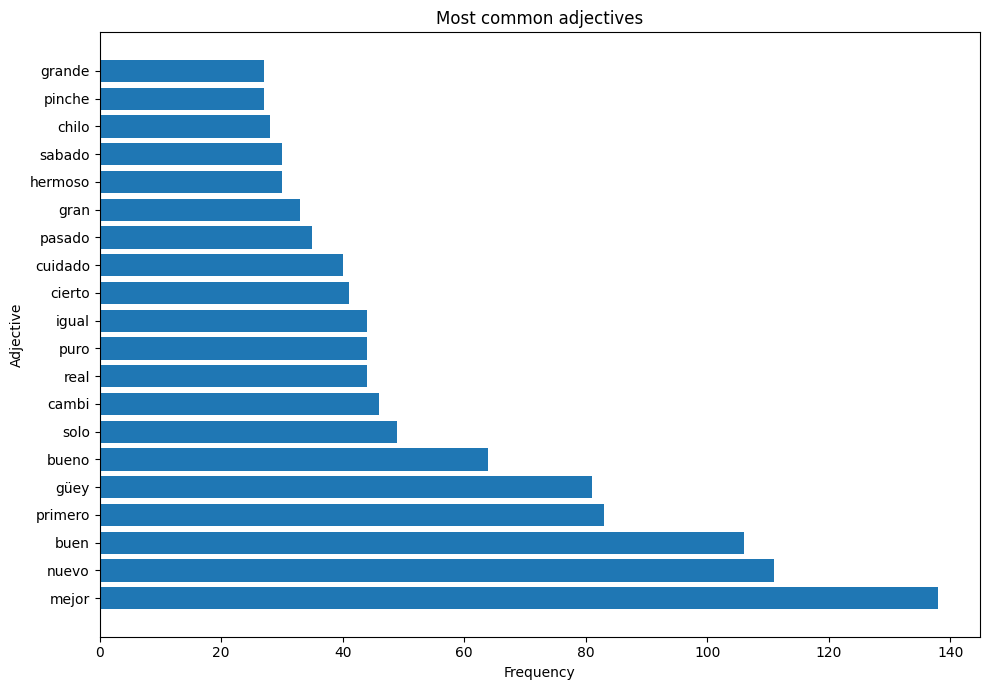

In [68]:
top_adjectives = (
    most_common_adjectives
    .head(20)
    .sort_values("count")
)

# plotly graph
fig = px.bar(
    top_adjectives,
    x="count",
    y="adjective",
    orientation="h",
    title="Most common adjectives",
    labels={
        "adjective": "Adjective",
        "count": "Frequency"
    }
)

fig.show()

# matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.barh(
    top_adjectives["adjective"],
    top_adjectives["count"],
)

plt.xlabel("Frequency")
plt.ylabel("Adjective")
plt.title("Most common adjectives")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

¿Qué otras preguntas interesantes puedes responder con los datos que tienes? ¿Qué otras gráficas o análisis puedes hacer?

- Quizás ver la proporción de emojis o mensajes de texto que manda cada miembro
- Ver quién manda más urls, videos o fotografías
- Frases más comunes


¿Qué aprendí?
- Una cosa es que github no tiene renderizado para las gráficas de plotly, esta es la razón por la cuál incluí el código para estas y para las de matplotlib
- Consolidé un poco más el proceso de generar el proyecto con el template de ccds

¿Qué me sorprendió?
- Las funciones que tiene spacy para quitar stop words por default
- Además de eso, la librería de spacy cómo tal, se me hace muy interesante